In [1]:
import os
import pandas as pd
import random
import shutil

data_path = r'C:\Users\chloe\OneDrive\Desktop\swallow EMG\data\participants\1\extracted signals'

In [2]:
os.chdir("..") 

from src import feature_extraction, models, utils, results

exclude = ['oral prep 0']
df, class_map = feature_extraction.make_df(data_path, exclude, all_features=False)

df

substance volume         1                                                 \
                           min  ssc     abs_diffs shannon_entropy median_freq   
0           0     10  -89.8215  432   8511.370464        3.307889        67.0   
1           0     10 -113.9200  440   8262.519721        2.937729        51.0   
2           0     10  -82.3953  427   8938.223938        3.289639        62.0   
3           0     10 -194.0030  432   9634.231501        2.507875        52.0   
4           0     10 -117.7260  394   9543.440074        3.205701        55.0   
..        ...    ...       ...  ...           ...             ...         ...   
440        10     20  -69.3289  396   8874.451929        3.528975        66.0   
441        10     20  -86.3076  421   9792.563997        3.453142        68.0   
442        10     20  -93.5527  417   8838.968969        3.245622        63.0   
443        10     20  -95.3684  390   9634.328738        3.493063        59.0   
444        10     20  -95.7571  403  11234.928474        3.549456        64.0   

                                 2  ...          21                       \
    peak_freq  bandwidth       min  ... median_freq peak_freq  bandwidth   
0        67.0  37.418943  -63.1080  ...         9.0       1.0  17.569146   
1        51.0  36.862048  -85.0561  ...         5.0       1.0  21.425524   
2        36.0  38.599395  -72.1325  ...         2.0       1.0  19.073876   
3        35.0  35.458660 -138.6000  ...         9.0       1.0  17.332390   
4        40.0  36.756485 -100.0970  ...         2.0       1.0  14.641707   
..        ...        ...       ...  ...         ...       ...        ...   
440      46.0  37.249948  -64.7040  ...         4.0       1.0  13.785925   
441      43.0  39.139085  -82.4918  ...         3.0       2.0  20.198134   
442      34.0  39.860416 -101.9280  ...         4.0       4.0  16.318277   
443      37.0  38.289810  -90.6453  ...         2.0       2.0  13.562179   
444      39.0  33.671782  -74.2673  ...         3.0       3.0  18.152696   

        22                                                                  
       min  ssc abs_diffs shannon_entropy median_freq peak_freq  bandwidth  
0   -15680  130    426580        4.040291         4.0       2.0  11.468772  
1   -12740  117    449540        4.537548         2.0       1.0  10.656156  
2   -13160  147    391580        4.487950         2.0       1.0   9.277570  
3   -12740   94    458780        4.410476         6.0      13.0   8.524833  
4   -14560  121    353780        4.641191         1.0       1.0   7.157294  
..     ...  ...       ...             ...         ...       ...        ...  
440 -11620   95    329560        3.997013         3.0       3.0   6.709104  
441 -23240  137    396620        4.062512         3.0       2.0   7.256091  
442 -11060  109    390740        4.641988         3.0       3.0   7.216130  
443 -15960   90    390040        4.344892         4.0       2.0   6.659081  
444  -9800  120    462560        4.518855         4.0       3.0   9.129009  

[445 rows x 156 columns]

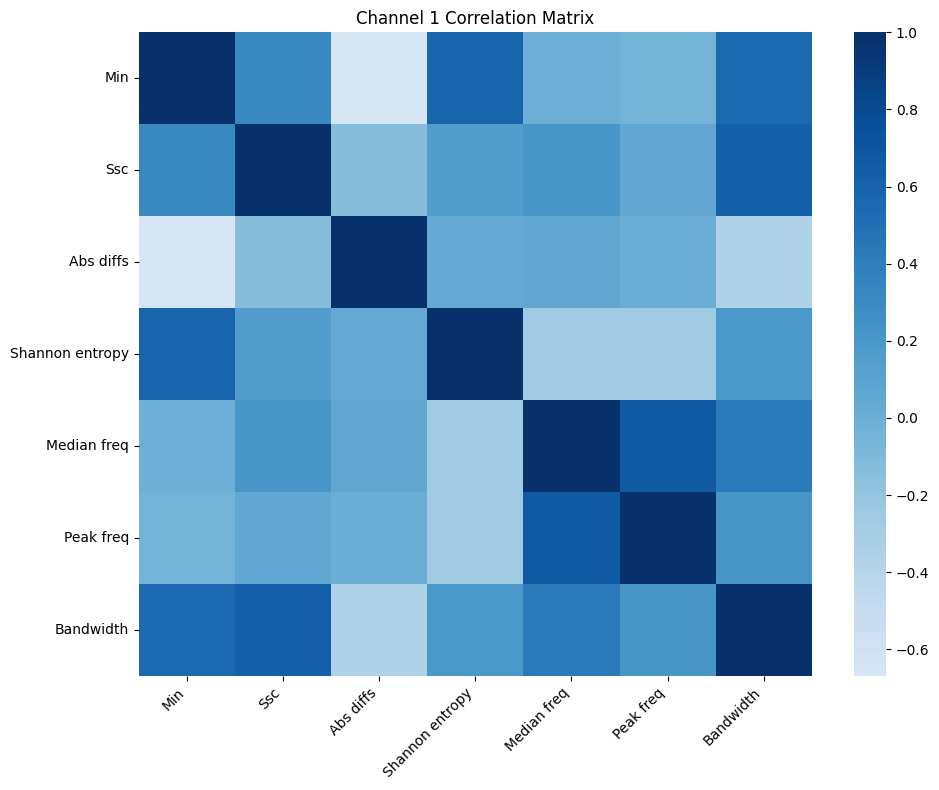

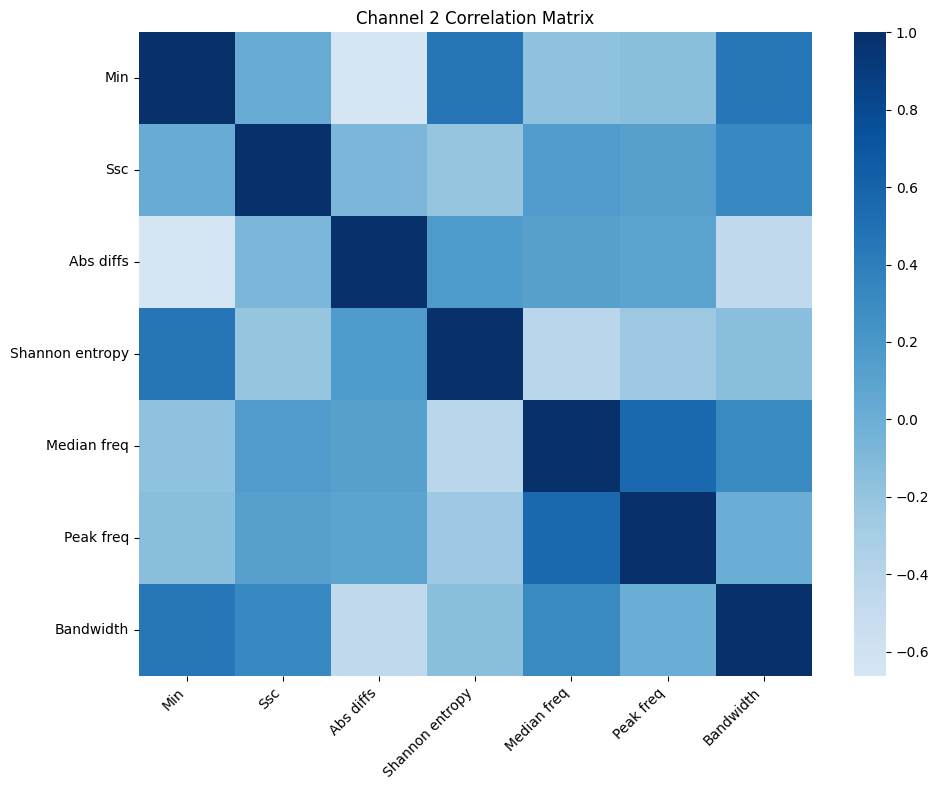

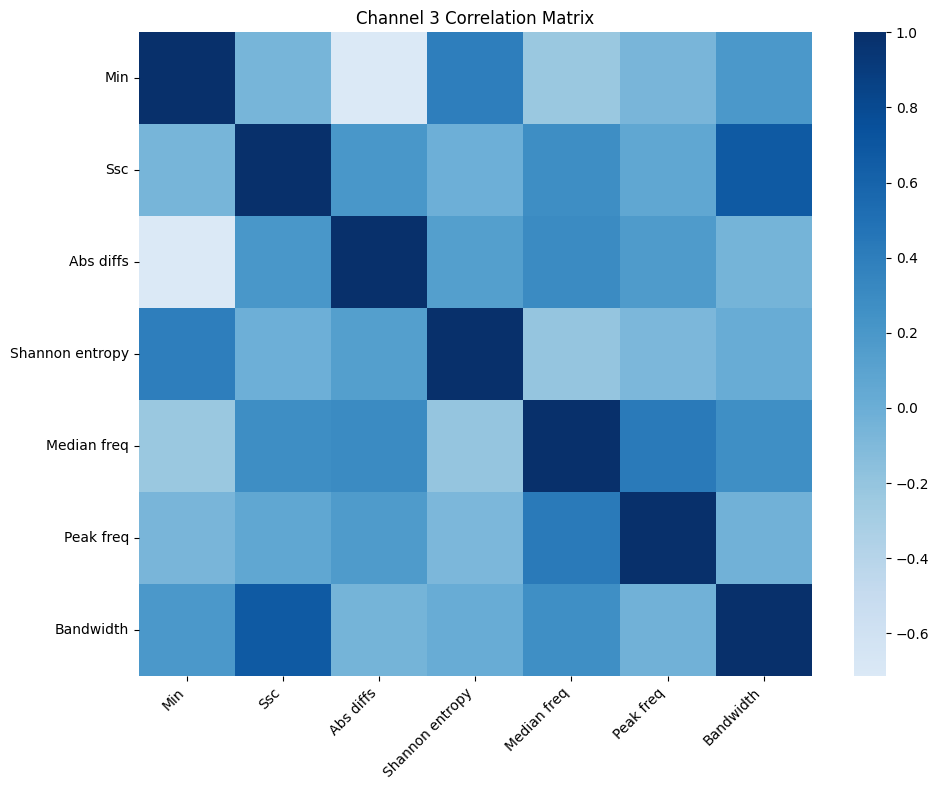

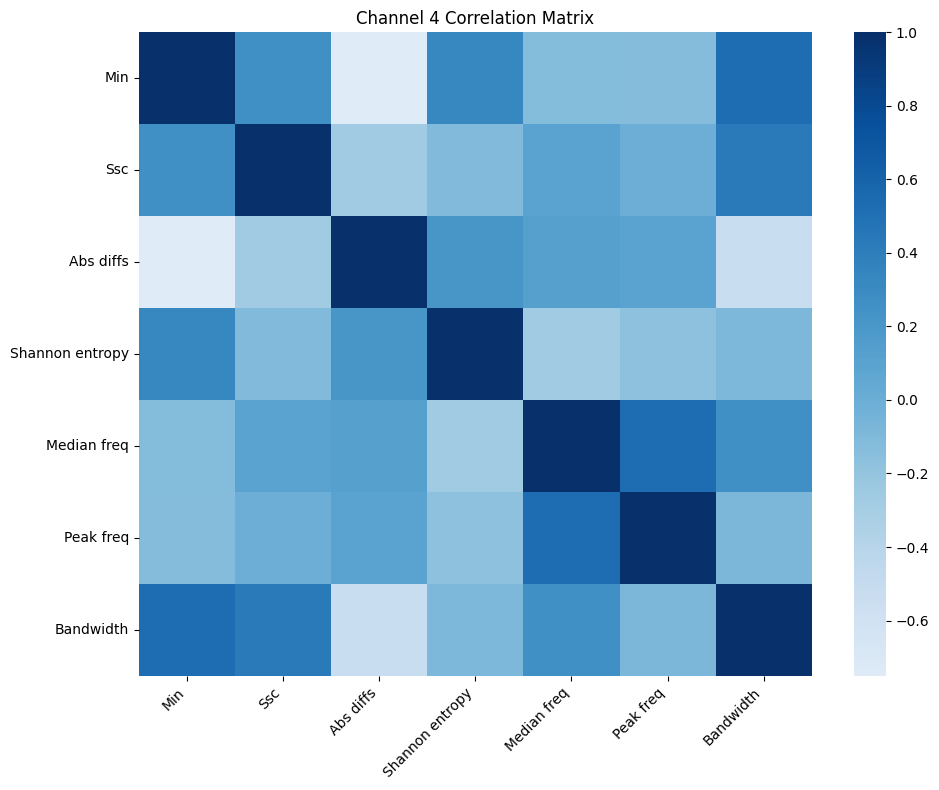

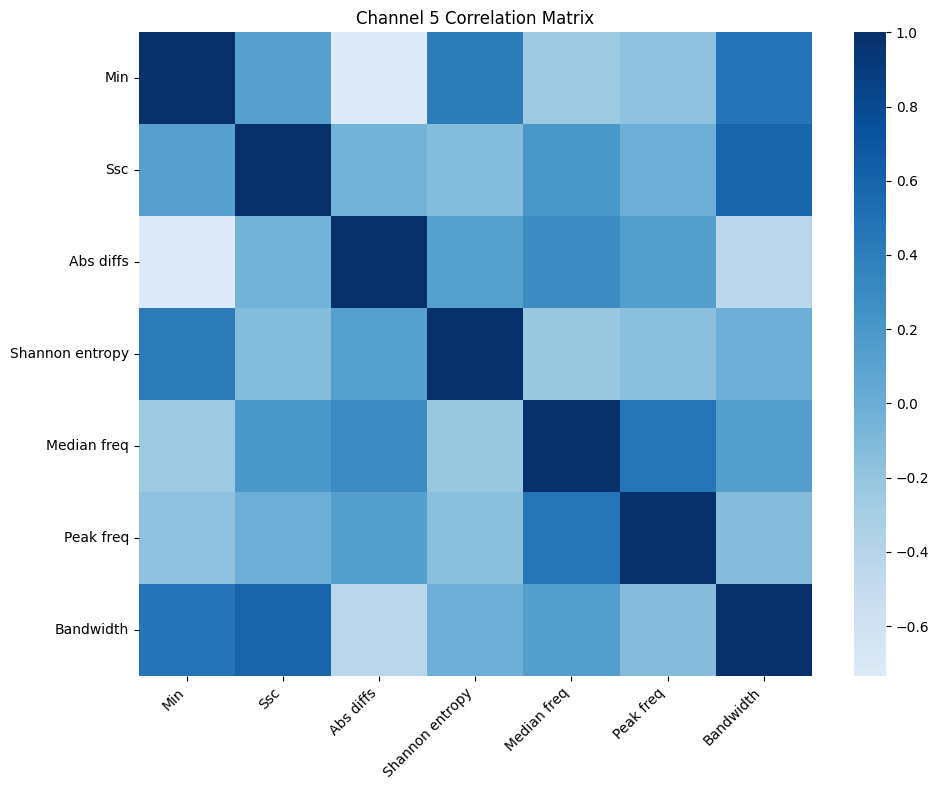

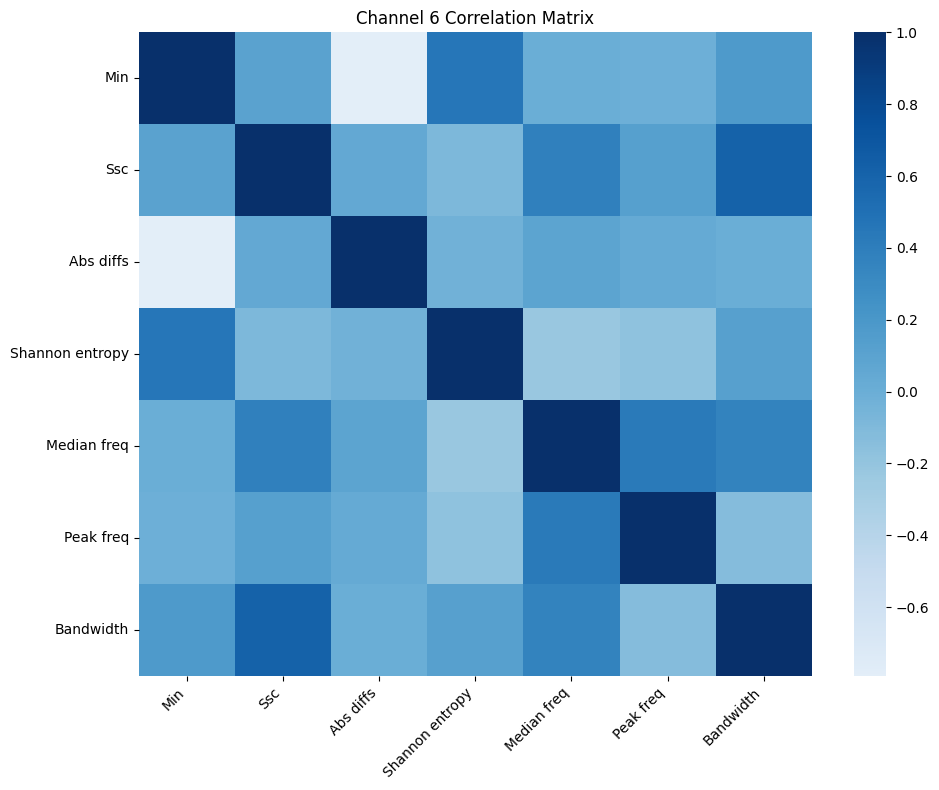

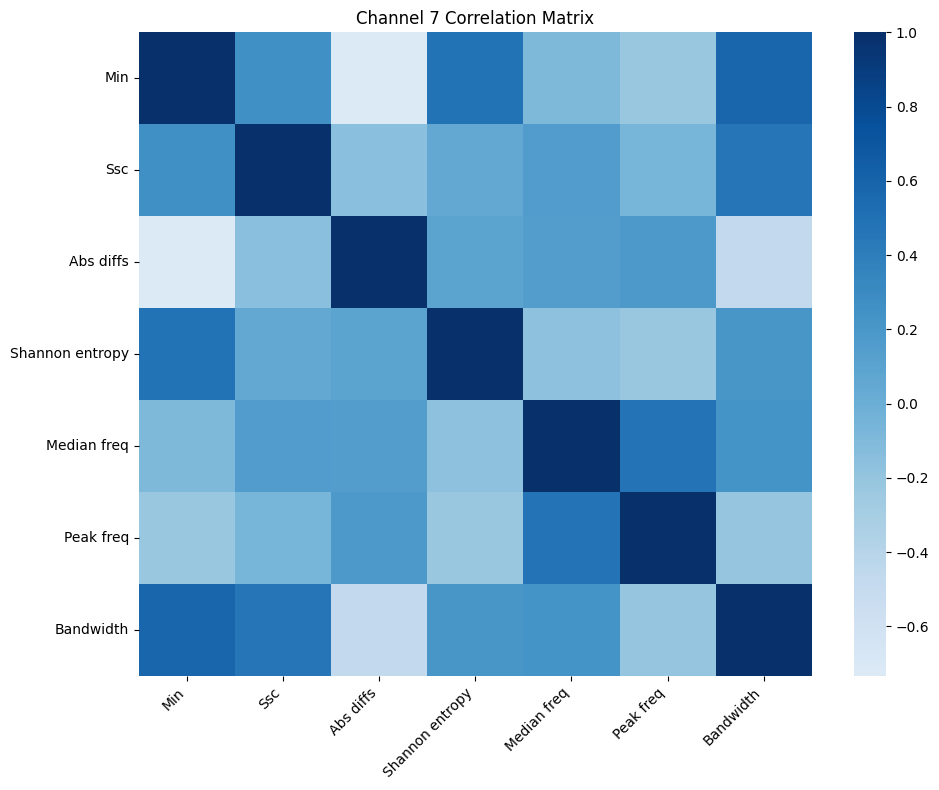

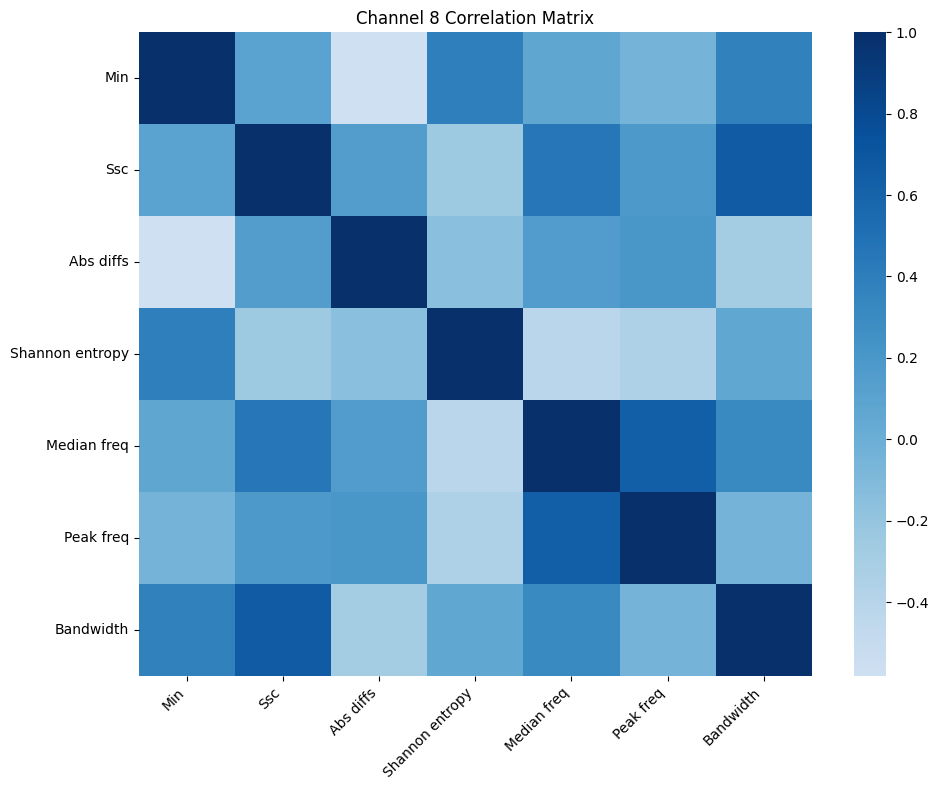

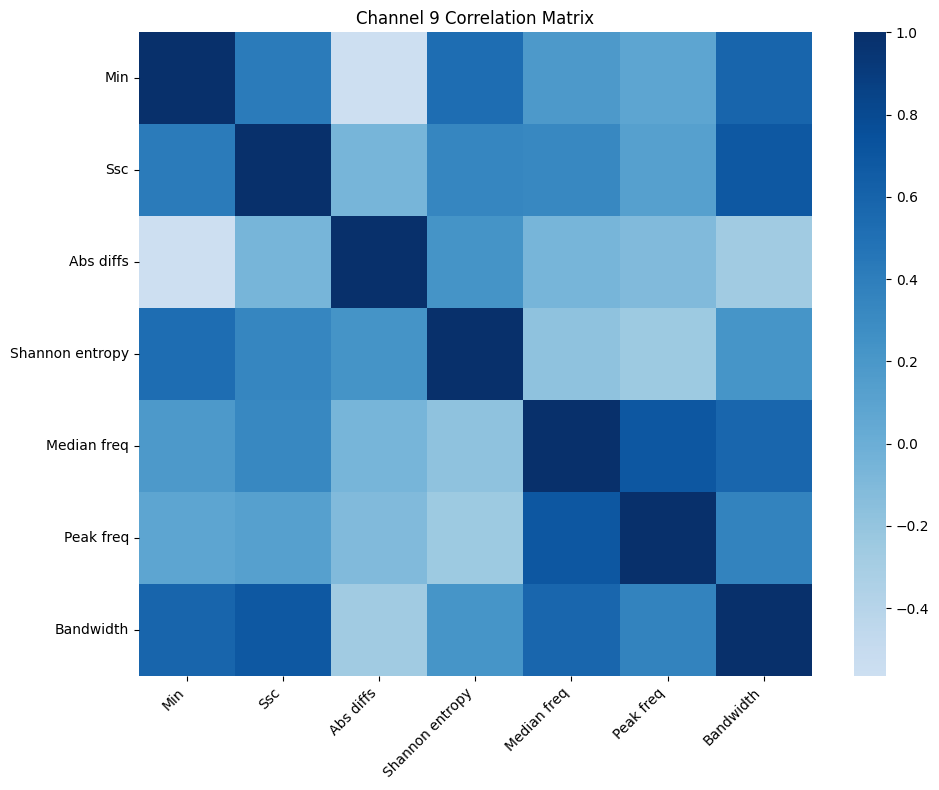

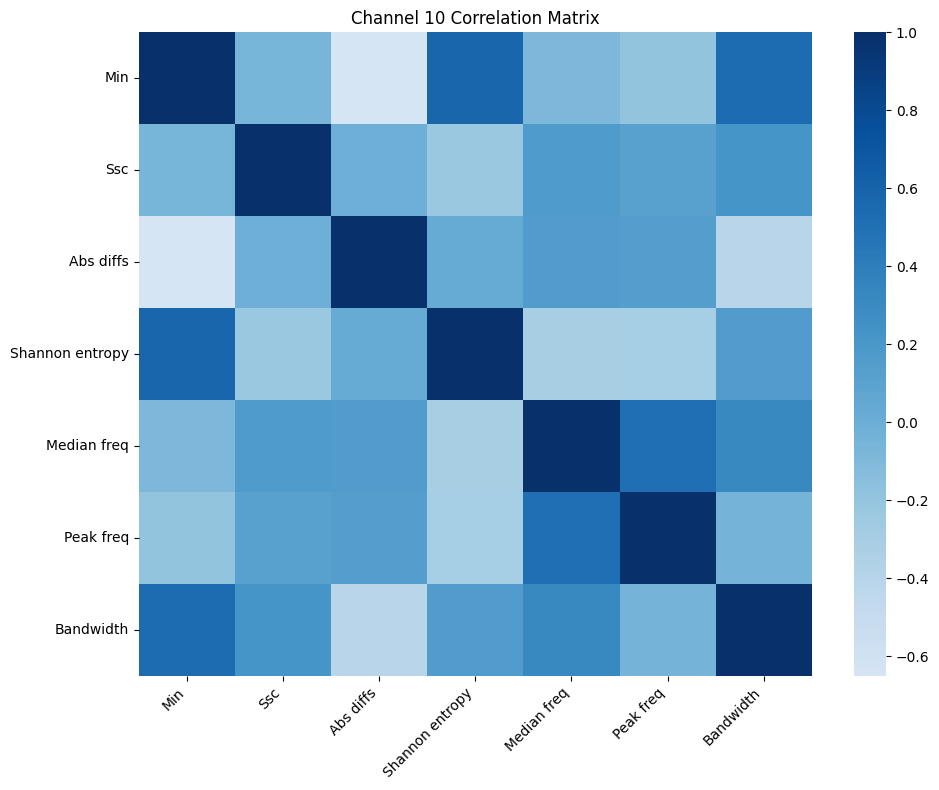

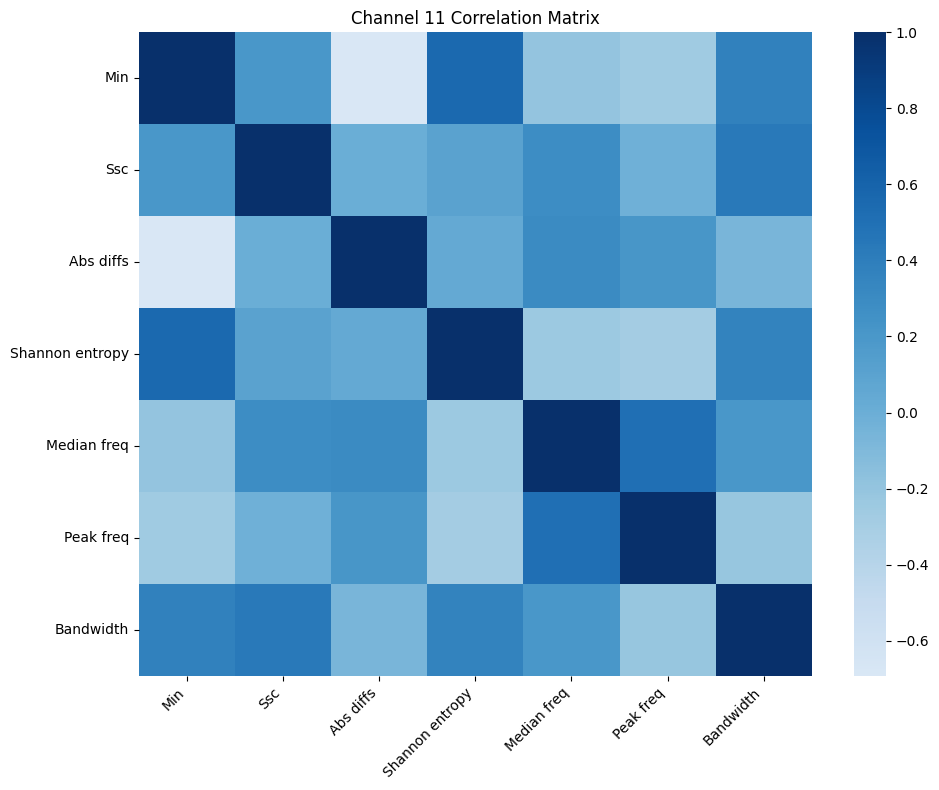

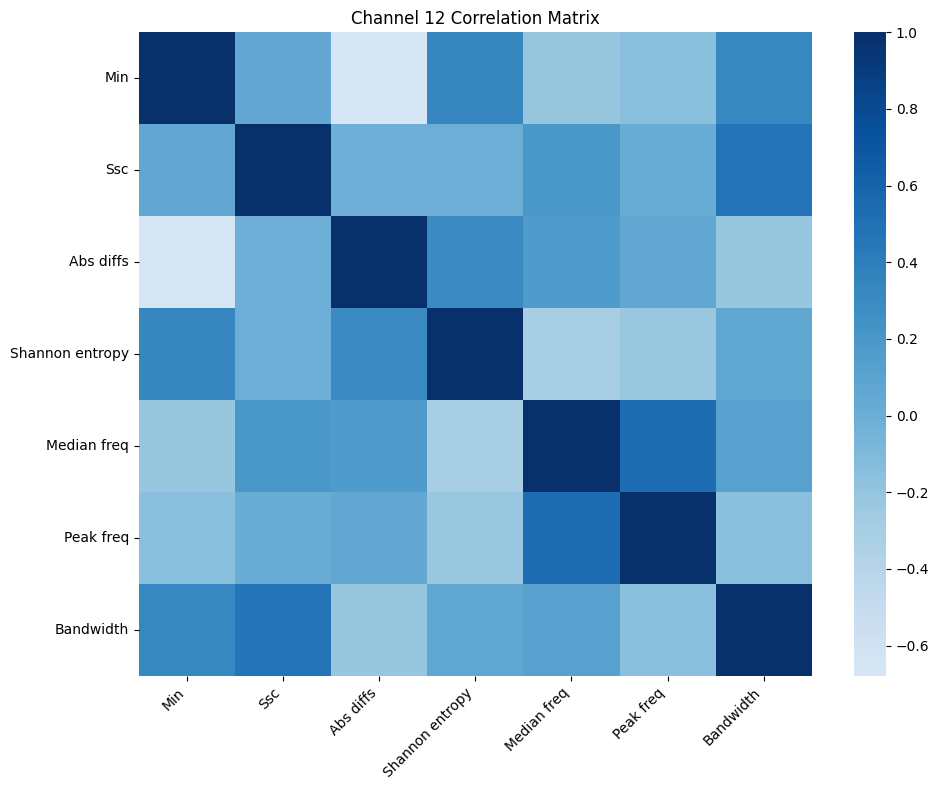

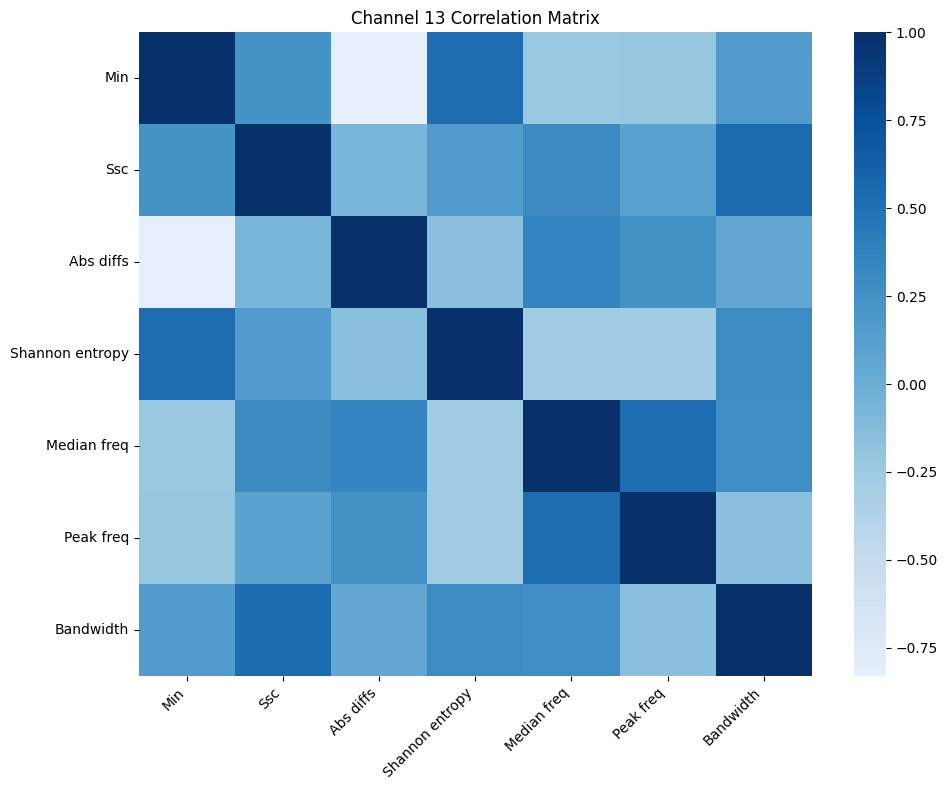

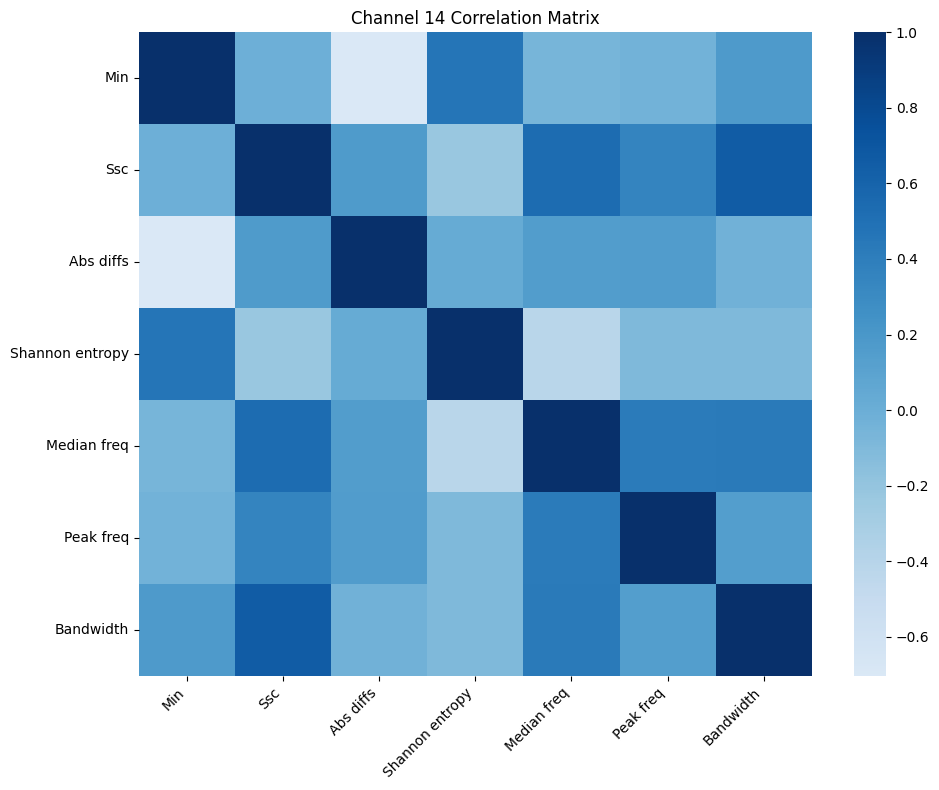

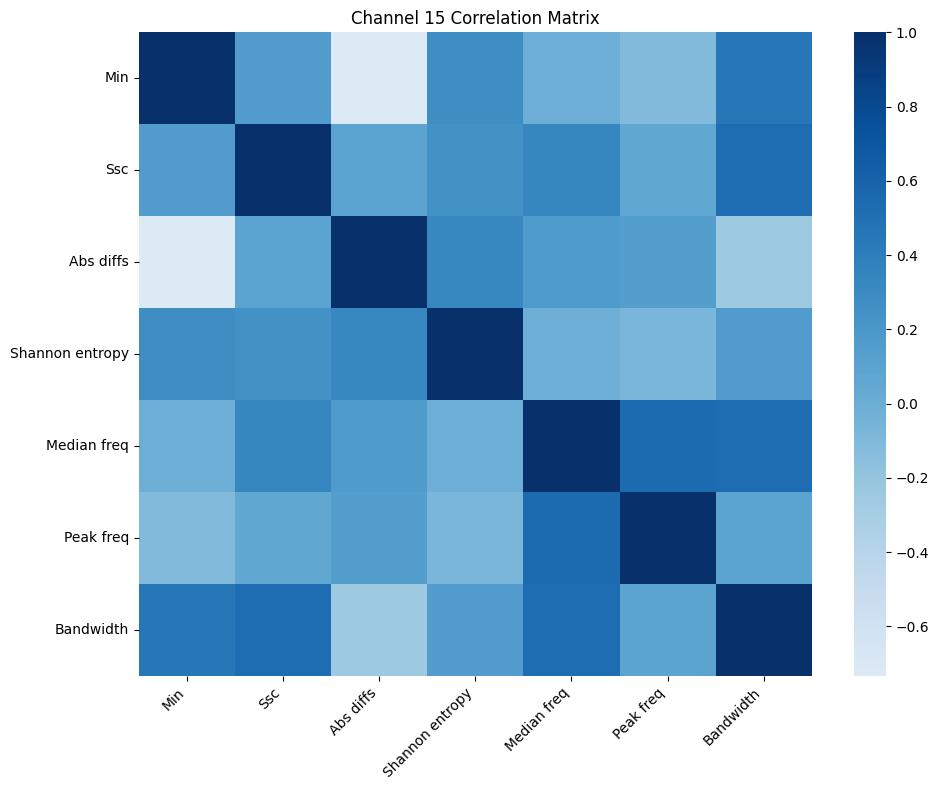

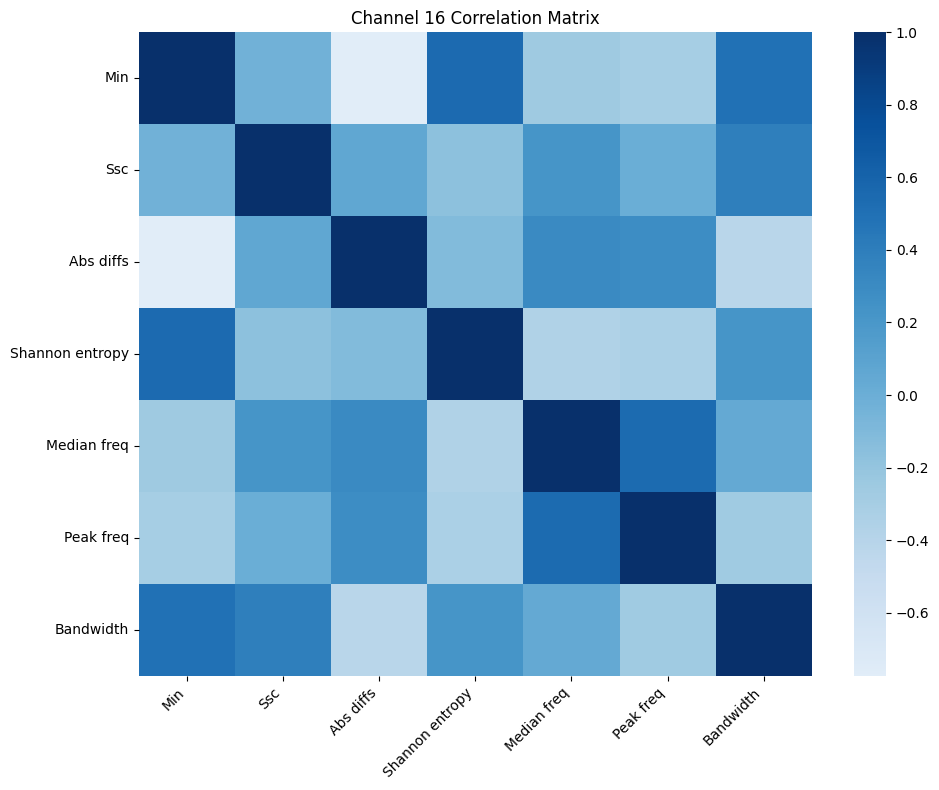

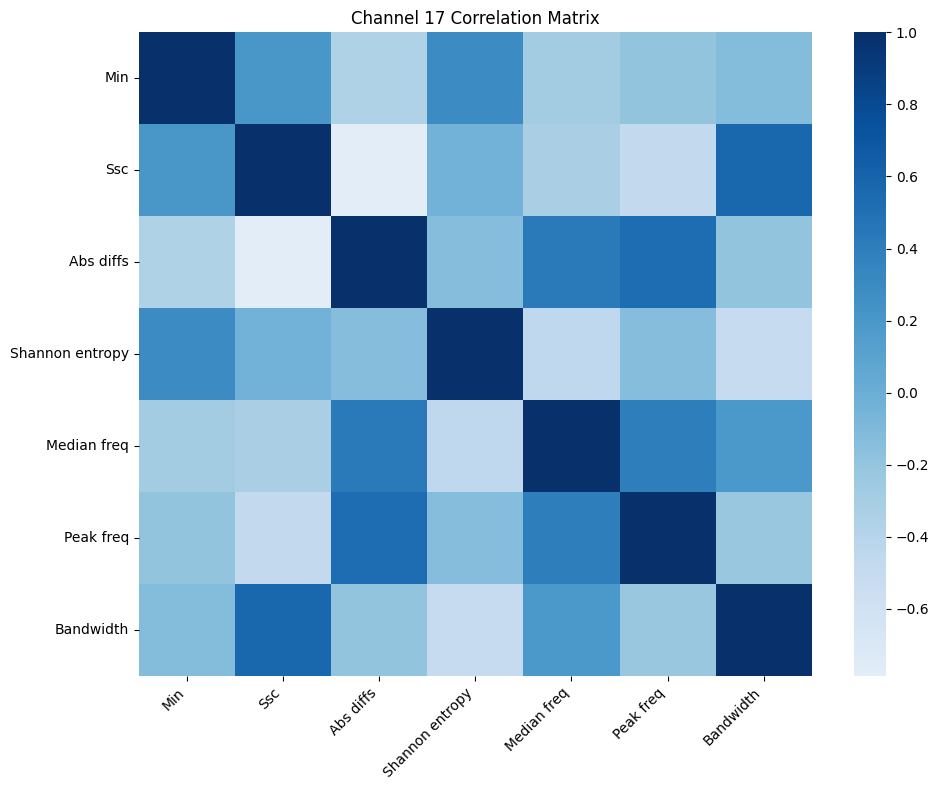

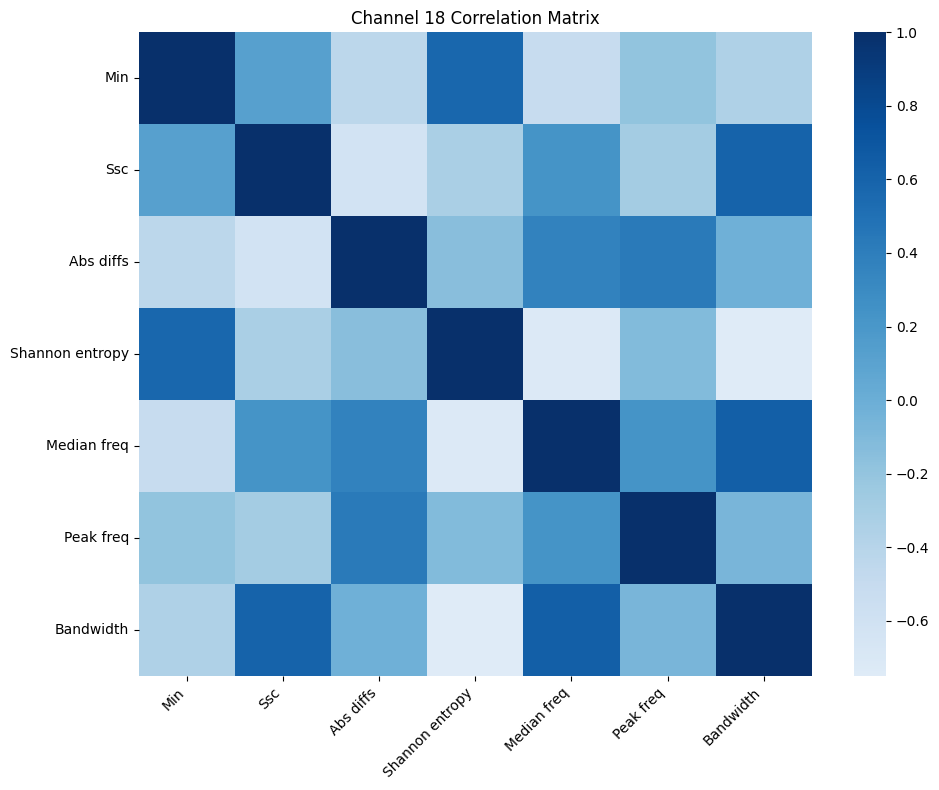

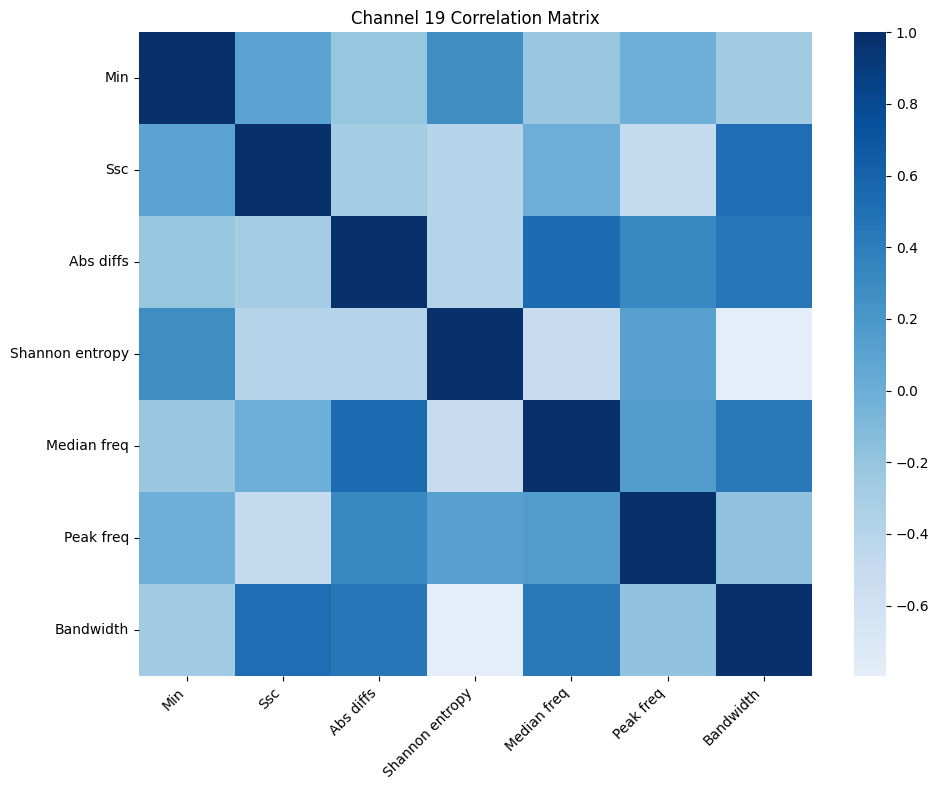

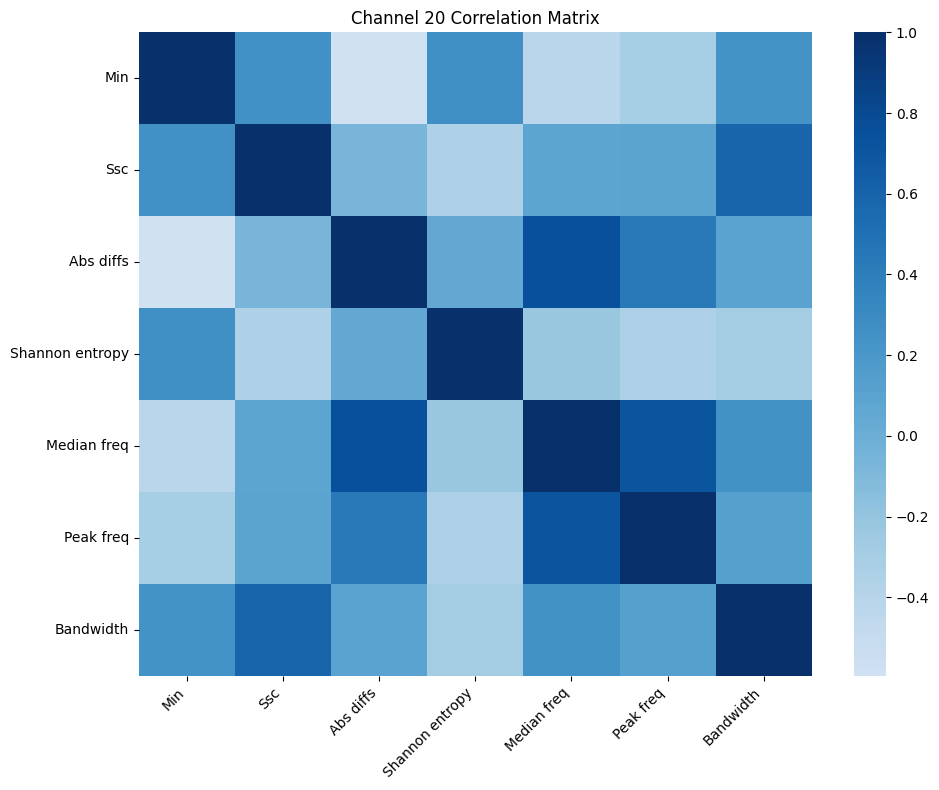

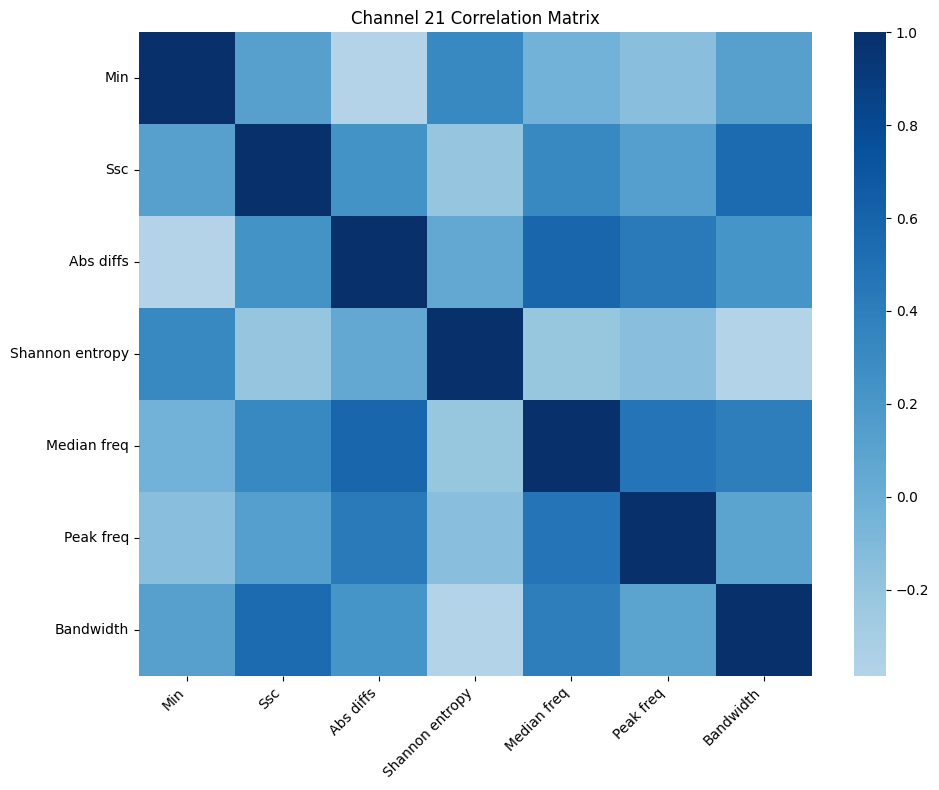

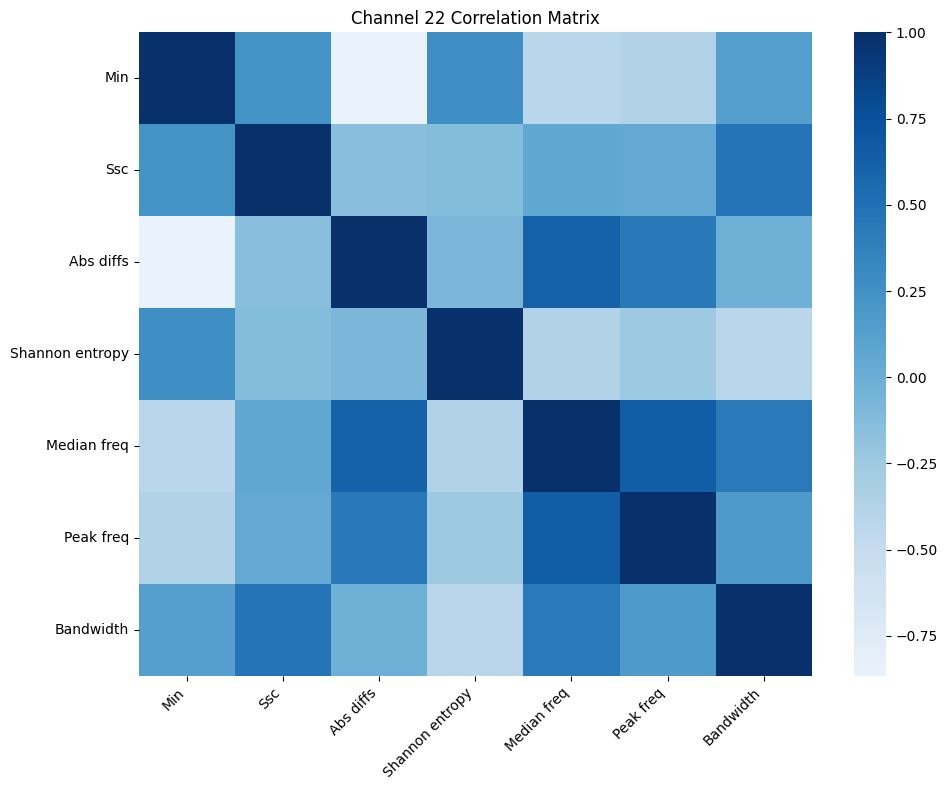

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def format_feature_name(name):
    return name.replace('_', ' ').capitalize()

for i in range(22):
    channel_df = df.iloc[:, i*7+2:i*7+9]
    channel_df.columns = channel_df.columns.get_level_values(1)
    corr = channel_df.corr()

    formatted_labels = [format_feature_name(name) for name in corr.columns]
    
    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(corr, cmap="Blues", center=0, 
                     xticklabels=formatted_labels, 
                     yticklabels=formatted_labels)
    
    plt.title("Channel " + str(i+1) + " Correlation Matrix")
    plt.xticks(rotation=45, ha='right')  
    plt.yticks(rotation=0) 
    plt.tight_layout()
    plt.show()

In [4]:
x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]
exact_accuracies, label_accuracies = models.train_multioutput_models(x, y, class_map, random_state=42, show_cm=False, show_metrics=True)

C:\Users\chloe\AppData\Local\Temp\ipykernel_7564\2590886700.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


SVM
Exact Match Accuracy: 73.0337
Per-Label Accuracies: [89.88764045 80.8988764 ]
----------------------------
KNN
Exact Match Accuracy: 84.2697
Per-Label Accuracies: [91.01123596 87.64044944]
----------------------------
Decision Tree
Exact Match Accuracy: 57.3034
Per-Label Accuracies: [79.7752809  73.03370787]
----------------------------
Naive Bayes
Exact Match Accuracy: 56.1798
Per-Label Accuracies: [86.51685393 65.16853933]
----------------------------
Logistic Regression
Exact Match Accuracy: 76.4045
Per-Label Accuracies: [93.25842697 82.02247191]
----------------------------
Gradient Boost
Exact Match Accuracy: 78.6517
Per-Label Accuracies: [89.88764045 85.39325843]
----------------------------


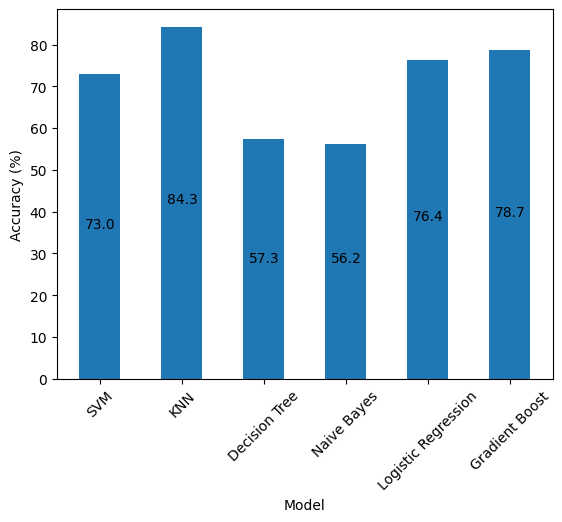

In [5]:
results.plot_acc(exact_accuracies)

# PCA

In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = df.drop(columns=['volume', 'substance'])
y = df[['substance', 'volume']]

x_train, x_test, y_train, y_test = models.make_split(x, y, 42)

pca = PCA(n_components=20)
x_train_pca = pca.fit_transform(x_train)
x_test_pca  = pca.transform(x_test)

print("Original shape:", x_train.shape)
print("Reduced shape (PCA):", x_train_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

Original shape: (356, 154)
Reduced shape (PCA): (356, 20)
Explained variance ratio: [0.20434229 0.1598712  0.11667614 0.07937008 0.05080448 0.03879868
 0.02948436 0.02085855 0.01606146 0.0143569  0.0127832  0.01204802
 0.01076408 0.00993596 0.0097426  0.00864693 0.00805805 0.00769931
 0.00707745 0.00687751]
Total explained variance: 0.8242572666874894


C:\Users\chloe\AppData\Local\Temp\ipykernel_7564\3904015201.py:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = df.drop(columns=['volume', 'substance'])


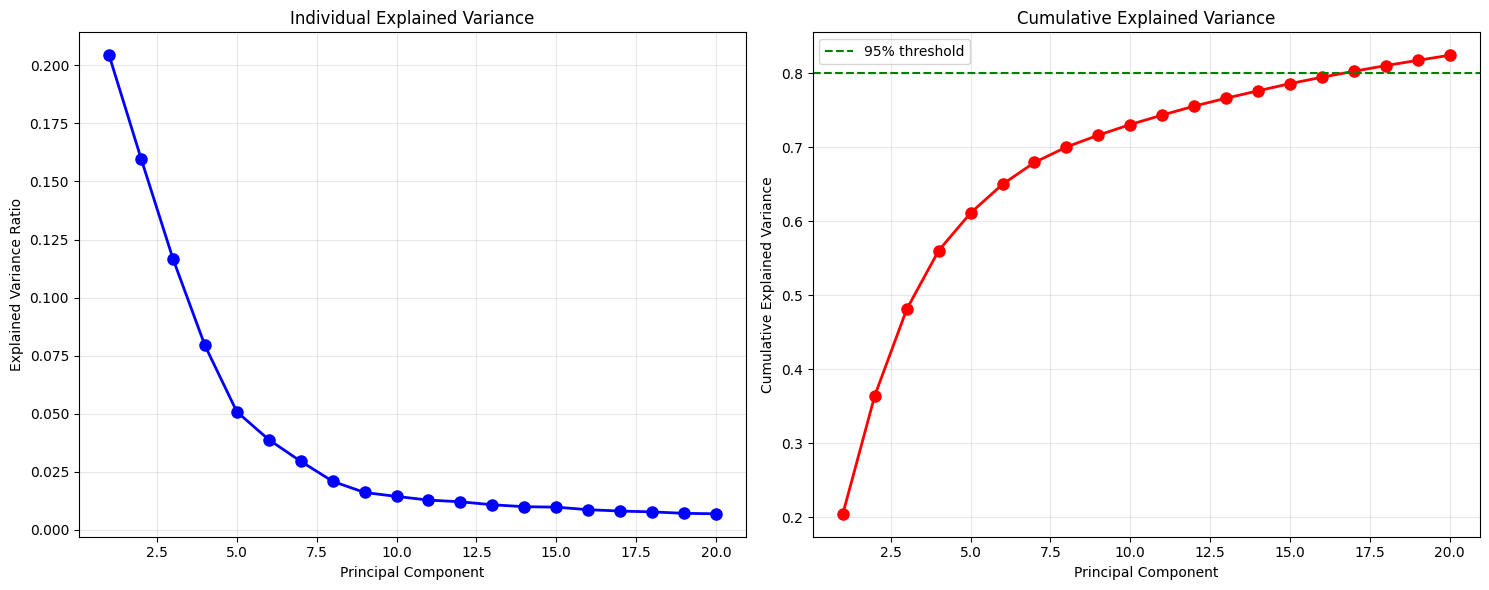

In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individual explained variance
ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 'ro-', linewidth=2, markersize=8)
ax2.axhline(y=0.8, color='g', linestyle='--', label='95% threshold')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

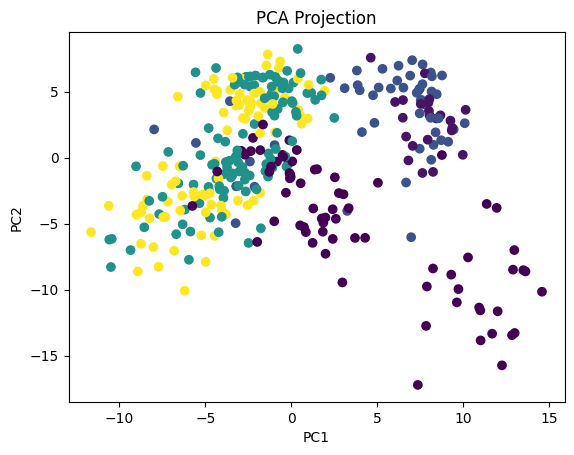

In [8]:
import matplotlib.pyplot as plt

plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train['volume'], cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

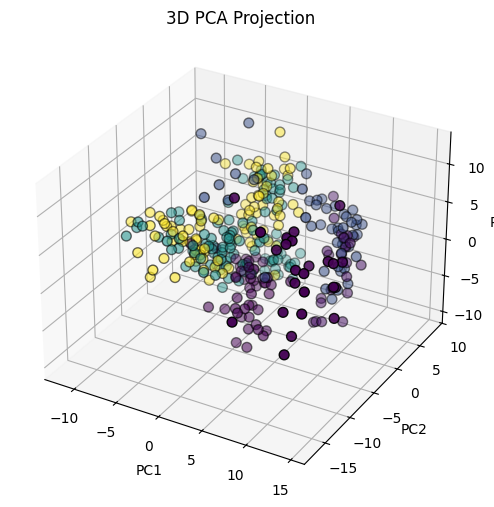

In [9]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# scatter plot in 3D
ax.scatter(
    x_train_pca[:,0], x_train_pca[:,1], x_train_pca[:,2],
    c=y_train['volume'], cmap='viridis', edgecolor='k', s=50
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Projection")

plt.show()

In [10]:
from src.models import multioutput_models
from sklearn.base import clone

def train_pca_models(x_train, x_test, y_train, y_test, substance_names):
    acc = []
    per_label_acc = []
    
    models_copy = [[name, clone(model)] for name, model in multioutput_models]

    substance_labels = [
        (k[5:] if k.lower().startswith('redu ') else k).capitalize()
        for k in substance_names.keys()
    ]
    
    for model in models_copy:
        model[1].fit(x_train, y_train)
        y_pred = model[1].predict(x_test)
    
        # Exact match accuracy (all labels correct)
        exact_match_accuracy = np.mean(np.all(y_test.values == y_pred, axis=1))
    
        # Per-label accuracy
        per_label_accuracy = (y_test == y_pred).mean(axis=0)
    
        acc.append(exact_match_accuracy * 100)
        per_label_acc.append(per_label_accuracy * 100)

    return acc, per_label_acc

In [11]:
pca_accuracies, pca_label_accuracies = train_pca_models(x_train_pca, x_test_pca, y_train, y_test, class_map)

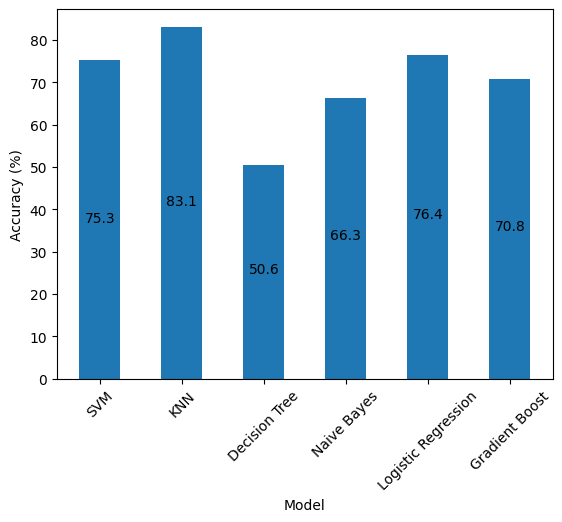

In [12]:
results.plot_acc(pca_accuracies)

# All features + PCA

C:\Users\chloe\AppData\Local\Temp\ipykernel_7564\1204995645.py:3: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  x = all_df.drop(columns=['volume', 'substance'])


SVM
Exact Match Accuracy: 88.7640
Per-Label Accuracies: [96.62921348 89.88764045]
----------------------------
KNN
Exact Match Accuracy: 88.7640
Per-Label Accuracies: [93.25842697 89.88764045]
----------------------------
Decision Tree
Exact Match Accuracy: 64.0449
Per-Label Accuracies: [79.7752809  76.40449438]
----------------------------
Naive Bayes
Exact Match Accuracy: 60.6742
Per-Label Accuracies: [85.39325843 67.41573034]
----------------------------
Logistic Regression
Exact Match Accuracy: 86.5169
Per-Label Accuracies: [96.62921348 88.76404494]
----------------------------
Gradient Boost
Exact Match Accuracy: 80.8989
Per-Label Accuracies: [89.88764045 86.51685393]
----------------------------


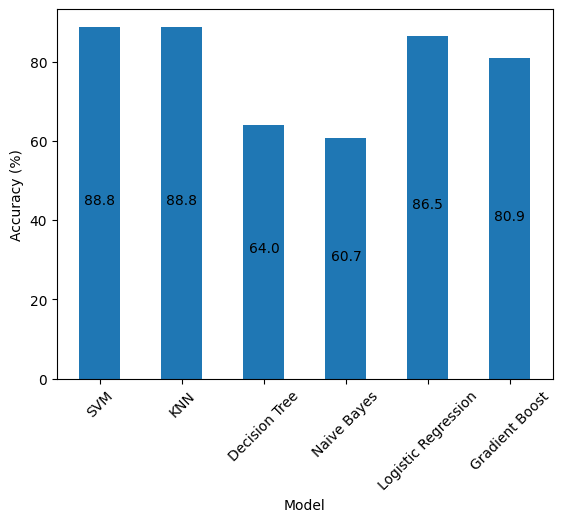

In [13]:
all_df, all_class_map = feature_extraction.make_df(data_path, exclude)

x = all_df.drop(columns=['volume', 'substance'])
y = all_df[['substance', 'volume']]
all_accuracies, all_label_accuracies = models.train_multioutput_models(x, y, all_class_map, random_state=42, show_cm=False, show_metrics=True)

results.plot_acc(all_accuracies)


In [18]:
x_train, x_test, y_train, y_test = models.make_split(x, y, 42)

pca = PCA(n_components=0.9)
x_train_pca = pca.fit_transform(x_train)
x_test_pca  = pca.transform(x_test)

print("Original shape:", x_train.shape)
print("Reduced shape (PCA):", x_train_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

Original shape: (356, 330)
Reduced shape (PCA): (356, 33)
Explained variance ratio: [0.26593841 0.17808028 0.09568895 0.06959618 0.05655341 0.03328689
 0.02499669 0.02177786 0.01662598 0.01283882 0.01184469 0.01029322
 0.00904907 0.00810847 0.00747499 0.00707048 0.00673757 0.00638229
 0.00557911 0.00508647 0.00501161 0.004631   0.0045231  0.00425751
 0.00389392 0.00369373 0.00362732 0.0034623  0.00330795 0.00315052
 0.00296243 0.00291488 0.00280265]
Total explained variance: 0.9012487476771959


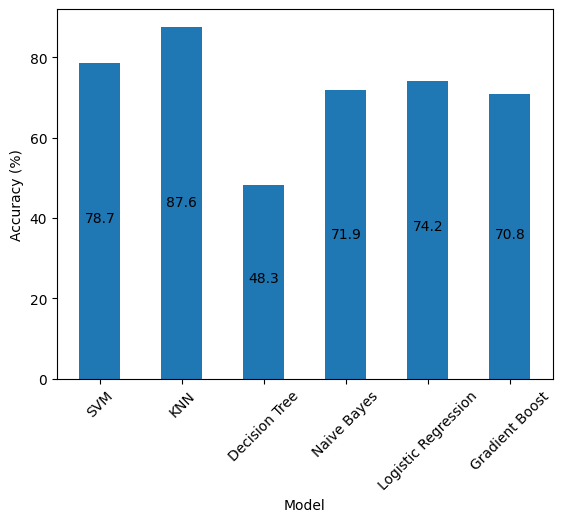

In [19]:
all_pca_accuracies, all_pca_label_accuracies = train_pca_models(x_train_pca, x_test_pca, y_train, y_test, all_class_map)

results.plot_acc(all_pca_accuracies)